In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [2]:
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
df_orders = pd.read_csv('../data/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'])
df_order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
df_order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv', parse_dates=['review_creation_date',
       'review_answer_timestamp'])
df_sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
df_customers = pd.read_csv('../data/olist_customers_dataset.csv')

In [4]:
dataframes = {
    'orders': df_orders,
    'order_items': df_order_items,
    'order_payments': df_order_payments,
    'order_reviews': df_order_reviews,
    'sellers': df_sellers,
    'customers': df_customers
}

for name, df in dataframes.items():
    print(f'{name}: {df.shape[0]:,} rows, {df.shape[1]} columns')

orders: 99,441 rows, 8 columns
order_items: 112,650 rows, 7 columns
order_payments: 103,886 rows, 5 columns
order_reviews: 99,224 rows, 7 columns
sellers: 3,095 rows, 4 columns
customers: 99,441 rows, 5 columns


## Exploratory Data Analysis

In [5]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [6]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

We see from this that there are missing values for `order_approved_at`,`order_delivered_carrier_date`, and `order_delivered_customer_date`, which means that this dataset contains orders that have not been delivered yet. 

In [7]:
df_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


## Master Dataframe

### Aggregating Order Items

In [8]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [9]:
df_order_items_agg = df_order_items.groupby('order_id').agg({'order_item_id': 'count', 'price': 'sum', 'freight_value': 'sum'}).rename(columns={
    'order_item_id': 'item_count'
}).reset_index()

In [10]:
df_order_items_agg.shape

(98666, 4)

### Aggregating Order Reviews

In [11]:
df_order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')

In [12]:
df_review_agg = df_order_reviews.groupby('order_id').agg({
    'review_score': 'mean',
    'review_comment_message': 'first'
}).reset_index()

In [13]:
df_review_agg.shape

(98673, 3)

### Slimming Down Customers

In [14]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [15]:
df_customers_slimmed = df_customers[['customer_id', 'customer_unique_id', 'customer_state']]

### Merging

In [16]:
df_master = df_orders\
    .merge(df_customers_slimmed, on='customer_id', how='left')\
    .merge(df_order_items_agg, on='order_id', how='left')\
    .merge(df_review_agg, on='order_id', how='left')

In [17]:
df_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,item_count,price,freight_value,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22,5.0,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20,5.0,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72,5.0,NaN


In [18]:
df_master.shape

(99441, 15)

## Add Calculated Columns

In [19]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   customer_unique_id             99441 non-null  str           
 9   customer_state                 99441 non-null  str           
 10  item_count                     98666 non-null  float64       
 11  price                     

In [20]:
df_master['delivery_days'] = (df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']).dt.days

df_master['delivery_delay'] = (df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']).dt.days

df_master['total_revenue'] = df_master['price'] + df_master['freight_value']

df_master['order_month'] = df_master['order_purchase_timestamp'].dt.strftime("%Y-%m")

In [21]:
df_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_state,item_count,price,freight_value,review_score,review_comment_message,delivery_days,delivery_delay,total_revenue,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,SP,1.0,29.99,8.72,4.0,"Não testei o produto ainda, mas ele veio corre...",8.0,-8.0,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,BA,1.0,118.70,22.76,4.0,Muito bom o produto.,13.0,-6.0,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,GO,1.0,159.90,19.22,5.0,NaN,9.0,-18.0,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,RN,1.0,45.00,27.20,5.0,O produto foi exatamente o que eu esperava e e...,13.0,-13.0,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,SP,1.0,19.90,8.72,5.0,NaN,2.0,-10.0,28.62,2018-02


In [22]:
df_master[['delivery_days', 'delivery_delay', 'total_revenue', 'order_month']].describe()

,delivery_days,delivery_delay,total_revenue
count,96476.000000,96476.000000,98666.000000
mean,12.094086,-11.876881,160.577638
std,9.551746,10.183854,220.466087
min,0.000000,-147.000000,9.590000
25%,6.000000,-17.000000,61.980000
50%,10.000000,-12.000000,105.290000
75%,15.000000,-7.000000,176.870000
max,209.000000,188.000000,13664.080000


## Analysis

### Total Revenue by Month

In [31]:
revenue_trend = df_master.groupby('order_month')['total_revenue'].sum().loc['2016-10':'2018-08'].reset_index()

In [34]:
revenue_trend.head()

,order_month,total_revenue
0,2016-10,56808.84
1,2016-12,19.62
2,2017-01,137188.49
3,2017-02,286280.62
4,2017-03,432048.59


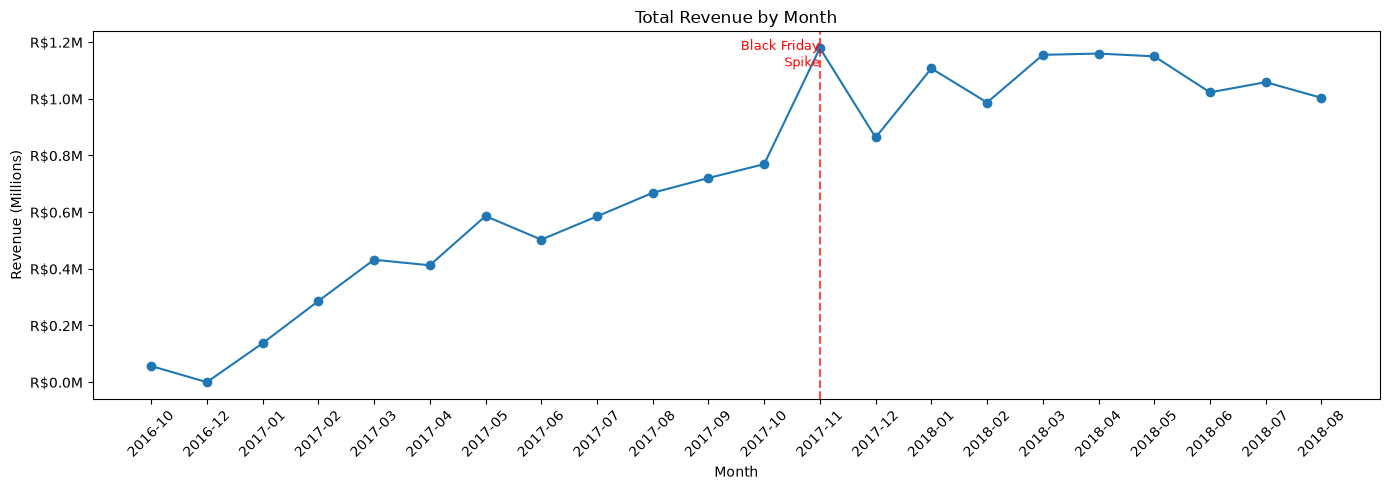

In [53]:
plt.figure(figsize=(14, 5))
plt.plot(revenue_trend['order_month'], revenue_trend['total_revenue'], marker='o')
plt.xticks(rotation=45)
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue (Millions)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.axvline('2017-11', color='red', linestyle='--', alpha=0.7)
plt.text(
    x='2017-11', 
    y=plt.gca().get_ylim()[1] * 0.9,
    s='Black Friday\nSpike',
    color='red',
    fontsize=9,
    ha='right'
)
plt.tight_layout()
plt.show()

> This chart shows us the total revenue by the month. We can see a clear spike at November 2017, which is where Black Friday is, so we can attribute the spike to that.
>
> We also see a dip around December 2016, which may be due to inacccurate data collection. 

### Review Score Distribution

In [82]:
counts = df_order_reviews['review_score'].value_counts().sort_index()
review_dist = pd.DataFrame({
    'review_score': counts.index,
    'count': counts.values,
    'percentage': counts.values / counts.sum() * 100
})

In [83]:
review_dist

,review_score,count,percentage
0,1,11424,11.513344
1,2,3151,3.175643
2,3,8179,8.242965
3,4,19142,19.291704
4,5,57328,57.776344


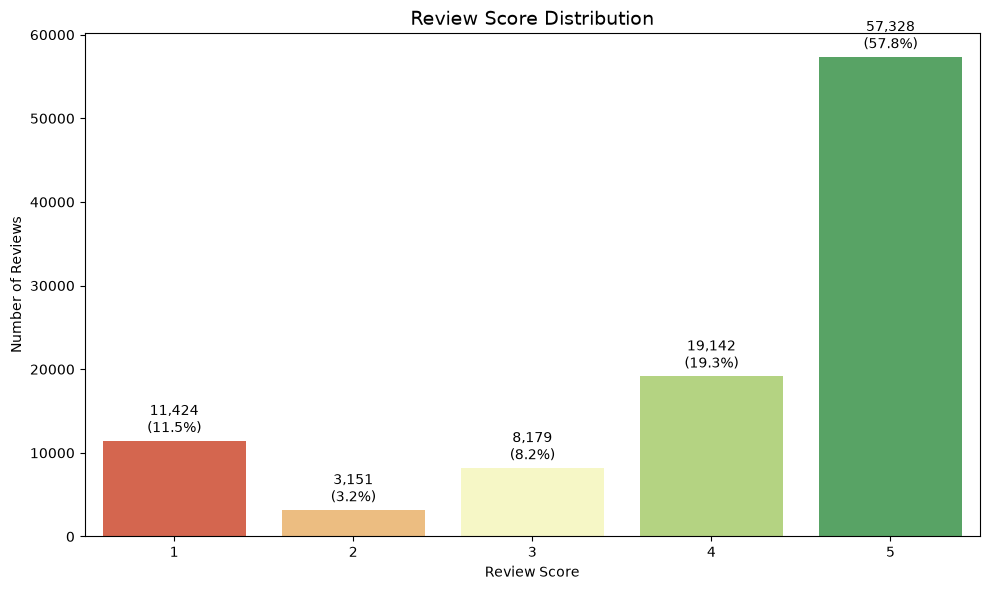

In [91]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=review_dist, x='review_score', y='count', palette='RdYlGn')
for bar, (_, row) in zip(ax.patches, review_dist.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{int(row["count"]):,}\n({row["percentage"]:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.title('Review Score Distribution', fontsize=14)
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

> The distribution is heavily skewed toward 5-star ratings (57.8%), with 4 and 5-star reviews combined accounting for 77.1% of all reviews.
>
> However, 1-star reviews represent the third most common rating at 11.5% — more than 2-star and 3-star combined — suggesting a bimodal satisfaction pattern where customers tend to either love or hate their experience, with little middle ground.